In [15]:
#练习1
import numpy as np
import timeit
import matplotlib.pyplot as plt
A=np.random.rand(1000,2000)#任务1
B=np.random.rand(2000,3000)

def normal_dot():
    return np.dot(A,B)
def way_at():
    return A@B
def way_matmul():
    return np.matmul(A,B)

t_dot=timeit.timeit(normal_dot,number=5)
t_at=timeit.timeit(way_at,number=5)
t_matmul=timeit.timeit(way_matmul,number=5)

print(f"{t_dot:.4f}")
print(f"{t_at:.4f}")
print(f"{t_matmul:.4f}")

arr_c=np.random.rand(1000,1000)#任务2
arr_c=np.ascontiguousarray(arr_c)
arr_f=np.asfortranarray(arr_c)
#行序列
cc=timeit.timeit(lambda:arr_c.sum(axis=1),number=100)
cf=timeit.timeit(lambda:arr_c.sum(axis=0),number=100)
#列序列
fc=timeit.timeit(lambda:arr_f.sum(axis=1),number=100)
ff=timeit.timeit(lambda:arr_f.sum(axis=0),number=100)

print(f"C序数组 行求和：{cc:.4f}s，列求和：{cf:.4f}s")
print(f"F序数组 行求和：{fc:.4f}s，列求和：{ff:.4f}s")

A=np.random.rand(2000,2000)#任务三
way1=A**2+2*A+1
way2=np.add(np.multiply(A,A),np.multiply(2,A),out=np.empty_like(A))
np.add(way2,1,out=way2)
print(np.allclose(way1,way2))

0.1936
0.1922
0.1940
C序数组 行求和：0.0359s，列求和：0.0208s
F序数组 行求和：0.0237s，列求和：0.0253s
True


每日对数收益率： [ 0.01980263  0.02898754 -0.01923136  0.03809985]


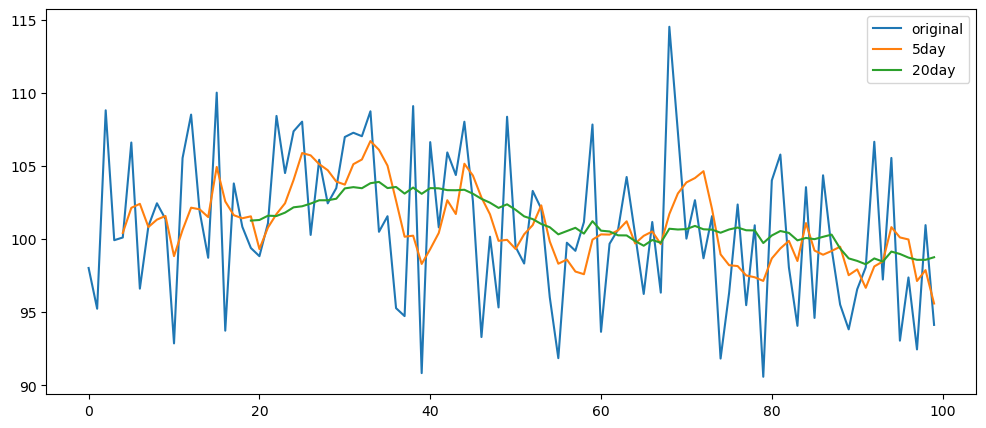

True
前10支股票年化波动率： [0.29063186 0.31809653 0.29642953 0.30019557 0.31310185 0.31209944
 0.29743366 0.33034286 0.30831469 0.3144914 ]
相关矩阵形状： (1000, 1000)


In [19]:
#练习2
#任务1
prices = np.array([100, 102, 105, 103, 107])
returns = np.log(prices[1:] / prices[:-1])
print("每日对数收益率：",returns)
log_returns_diff = np.diff(np.log(prices))
price_series = np.random.normal(loc=100, scale=5, size=100)
#任务2
wimdow=5
def moving_avg_conv(data, window):
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode="valid")
ma5 = moving_avg_conv(price_series, 5)
ma20 = moving_avg_conv(price_series, 20)
plt.figure(figsize=(12,5))
plt.plot(price_series, label="original")
plt.plot(np.arange(4, len(price_series)), ma5, label="5day")
plt.plot(np.arange(19, len(price_series)), ma20, label="20day")
plt.legend()
plt.show()

#任务3
log_returns_diff = np.diff(np.log(prices))
print(np.allclose(log_returns, log_returns_diff))
stock_returns = np.random.normal(0, 0.02, size=(1000, 252))
daily_std = np.std(stock_returns, axis=1)
annual_vol = daily_std * np.sqrt(252)
print("前10支股票年化波动率：", annual_vol[:10])
corr_matrix = np.corrcoef(stock_returns)
print("相关矩阵形状：", corr_matrix.shape)


In [21]:
"""1. 矩阵乘法性能差异原因
底层 BLAS 库：三者均调用优化线性代数库，但@/matmul专门针对二维矩阵场景做分支优化；
语义区分：np.dot兼容向量内积、张量缩并，内部多分支判断带来微小开销；matmul仅实现矩阵乘法，逻辑更简洁；
广播机制：高维张量运算时matmul广播规则更直观稳定，dot会将后两维视为矩阵，易出错。
内存速度差异核心
计算机 CPU 缓存优先读取连续内存块：
C 序行连续：逐行求和时内存连续，缓存复用率高；跨列访问内存跳跃，缓存失效频繁；
F 序列连续：列求和速度更快，行遍历则内存离散，性能暴跌；
处理超大数组时，优先调整遍历维度匹配存储顺序，或用ascontiguousarray转换布局。
2. 金融数据分析向量化重要性
性能：NumPy 向量化运算由 C 底层执行，规避 Python 循环的 GIL 开销，上万条行情数据运算速度提升百倍；
简洁：对数收益、移动平均、协方差矩阵仅 1~2 行代码，避免多层 for 循环冗余；
精度：原生循环易出现浮点数累积误差，NumPy 底层 ufunc 运算精度可控；
工程化：批量回测、蒙特卡洛模拟、风险矩阵计算必须依赖向量化才能落地。
3,可以用几何布朗运动模型模拟蒙特卡洛模拟股票价格
计算代数以及大量需要以列计算时该用order='f'，
"""

'1. 矩阵乘法性能差异原因\n底层 BLAS 库：三者均调用优化线性代数库，但@/matmul专门针对二维矩阵场景做分支优化；\n语义区分：np.dot兼容向量内积、张量缩并，内部多分支判断带来微小开销；matmul仅实现矩阵乘法，逻辑更简洁；\n广播机制：高维张量运算时matmul广播规则更直观稳定，dot会将后两维视为矩阵，易出错。\n2. 内存布局速度差异核心\n计算机 CPU 缓存优先读取连续内存块：\nC 序行连续：逐行求和时内存连续，缓存复用率高；跨列访问内存跳跃，缓存失效频繁；\nF 序列连续：列求和速度更快，行遍历则内存离散，性能暴跌；\n处理超大数组时，优先调整遍历维度匹配存储顺序，或用ascontiguousarray转换布局。\n3. 金融数据分析向量化重要性\n性能：NumPy 向量化运算由 C 底层执行，规避 Python 循环的 GIL 开销，上万条行情数据运算速度提升百倍；\n简洁：对数收益、移动平均、协方差矩阵仅 1~2 行代码，避免多层 for 循环冗余；\n精度：原生循环易出现浮点数累积误差，NumPy 底层 ufunc 运算精度可控；\n工程化：批量回测、蒙特卡洛模拟、风险矩阵计算必须依赖向量化才能落地。'